# Phase 4: Model Development and Evaluation

**Goal:** Train, tune, and evaluate six different machine learning regression models on the feature-engineered dataset. We will split the data into 80% training and 20% test splits, perform leak-free preprocessing (fitting encoders and scalers on the training split only), conduct hyperparameter tuning with cross-validation on a representative sample, shortlist features using tree-based importances, compare all models on MAE, RMSE, MSE, and R², and save the best model alongside all fitted preprocessors for dashboard deployment.

In [1]:
# Setup and configuration
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Model Families
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Set random seed for reproducibility
np.random.seed(42)

# Plot saving helper
def save_plot(fig, name, stage):
    folder = f"../outputs/plots/{stage}"
    os.makedirs(folder, exist_ok=True)
    path = f"{folder}/{name}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved: {path}")

print("Setup completed successfully.")

Setup completed successfully.


## Step 1: Load Feature-Engineered Dataset

We will load the feature-engineered dataset from `data/interim/feature_engineered_dataset.csv`.

In [2]:
fe_path = '../data/interim/feature_engineered_dataset.csv'
if not os.path.exists(fe_path):
    fe_path = 'data/interim/feature_engineered_dataset.csv'

df = pd.read_csv(fe_path)
print(f"Feature engineered dataset loaded. Shape: {df.shape}")

Feature engineered dataset loaded. Shape: (250000, 61)


## Step 2: Train/Test Split

We will split the dataset into a **80% training set** and a **20% test set** using `random_state=42`. It is critical that all encoding and scaling fit operations occur only on the training set to prevent data leakage.

In [3]:
# Define features (X) and target (y)
# We drop target columns, direct leakage columns (like Price_per_SqFt, price_per_sqft, price_per_bhk, log_price), and ID
drop_cols = ['ID', 'Price_in_Lakhs', 'Price_per_SqFt', 'price_per_sqft', 'price_per_bhk', 'log_price', 'price_bracket', 'city_target_enc_demo']
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['Price_in_Lakhs']  # We will use original price for metric calculation, but we can fit on log_price
y_log = np.log1p(y)        # Log-transformed target

# Split data
X_train, X_test, y_train, y_test, y_train_log, y_test_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (200000, 53), y_train shape: (200000,)
X_test shape: (50000, 53), y_test shape: (50000,)


## Step 3: Leak-Free Encoding & Target Encoding

We will implement standard One-Hot Encoding for low-cardinality nominal columns, and **Target/Mean Encoding** for the high-cardinality `Locality` and `City` columns. The target encoding is fit **only on the training split** and mapped to the test split. Any unseen categories in the test split are filled with the global training mean.

In [4]:
# 1. Target Encoding for City and Locality (Fit on train, map to test)
city_target_map = y_train.groupby(X_train['City']).mean().to_dict()
locality_target_map = y_train.groupby(X_train['Locality']).mean().to_dict()
global_mean_price = y_train.mean()

# Create target encoded features
X_train_encoded = X_train.copy()
X_test_encoded = X_test.copy()

X_train_encoded['city_target_enc'] = X_train['City'].map(city_target_map)
X_train_encoded['locality_target_enc'] = X_train['Locality'].map(locality_target_map)

X_test_encoded['city_target_enc'] = X_test['City'].map(city_target_map).fillna(global_mean_price)
X_test_encoded['locality_target_enc'] = X_test['Locality'].map(locality_target_map).fillna(global_mean_price)

# 2. One-Hot Encoding for remaining nominal low-cardinality features
ohe_cols = ['Property_Type', 'Facing', 'Owner_Type', 'Availability_Status']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Fit on train, transform both
ohe_train_arr = ohe.fit_transform(X_train[ohe_cols])
ohe_test_arr = ohe.transform(X_test[ohe_cols])
ohe_feature_names = ohe.get_feature_names_out(ohe_cols)

ohe_train_df = pd.DataFrame(ohe_train_arr, columns=ohe_feature_names, index=X_train.index)
ohe_test_df = pd.DataFrame(ohe_test_arr, columns=ohe_feature_names, index=X_test.index)

# Concatenate one-hot encoded columns and drop original categorical columns
drop_cat_cols = ['State', 'City', 'Locality', 'Property_Type', 'Facing', 'Owner_Type', 'Availability_Status', 
                 'Amenities', 'Furnished_Status', 'Public_Transport_Accessibility', 'Parking_Space', 
                 'Security', 'floor_category', 'property_age_category', 'population_density_category', 'property_type_grouped', 'city_tier']

X_train_encoded = pd.concat([X_train_encoded.drop(columns=[c for c in drop_cat_cols if c in X_train_encoded.columns]), ohe_train_df], axis=1)
X_test_encoded = pd.concat([X_test_encoded.drop(columns=[c for c in drop_cat_cols if c in X_test_encoded.columns]), ohe_test_df], axis=1)

print(f"Encoded X_train shape: {X_train_encoded.shape}")
print(f"Encoded X_test shape: {X_test_encoded.shape}")
print("Sample of encoded training columns:")
print(X_train_encoded.head(3))

Encoded X_train shape: (200000, 50)
Encoded X_test shape: (50000, 50)
Sample of encoded training columns:
        BHK  Size_in_SqFt  Year_Built  Floor_No  Total_Floors  Nearby_Schools  \
75381     5          4189        1996         8            14               2   
65569     2          4651        2020        10            11              10   
163473    1          1354        1992         1            18               9   

        Nearby_Hospitals  Crime_Rate_Per_Lakh  area_per_bhk  is_studio  ...  \
75381                  2                449.1         837.8          0  ...   
65569                  6                988.8        2325.5          0  ...   
163473                 7                988.8        1354.0          0  ...   

        Property_Type_Villa  Facing_East  Facing_North  Facing_South  \
75381                   0.0          0.0           0.0           0.0   
65569                   1.0          1.0           0.0           0.0   
163473                  0.0         

## Step 4: Feature Scaling

We will fit a `StandardScaler` **only on the training split** and use it to transform the test split. This is essential for linear regression (regularization), while tree models can bypass scaling.

In [5]:
# Standard Scaling
scaler = StandardScaler()
scaled_features = X_train_encoded.columns.tolist()

# Fit on train, transform both
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=scaled_features, index=X_train_encoded.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=scaled_features, index=X_test_encoded.index)

print("Feature scaling completed. Training features mean ~0 and std ~1.")
print(X_train_scaled.iloc[:, :5].describe().loc[['mean', 'std']])

Feature scaling completed. Training features mean ~0 and std ~1.
               BHK  Size_in_SqFt    Year_Built      Floor_No  Total_Floors
mean -1.831779e-16 -1.350031e-16 -5.160175e-15  1.358558e-16 -9.322321e-17
std   1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00  1.000003e+00


## Step 5: Feature Selection & Shortlisting

We will fit a fast `RandomForestRegressor` on a sampled subset of the training set (15,000 rows to ensure speed) to extract feature importances. We will select the top **15 features** as our shortlist and compare model performance.

C:\Users\ratha\AppData\Local\Temp\ipykernel_8212\709302975.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='mako', ax=ax)


Saved: ../outputs/plots/model/top_15_feature_importances.png


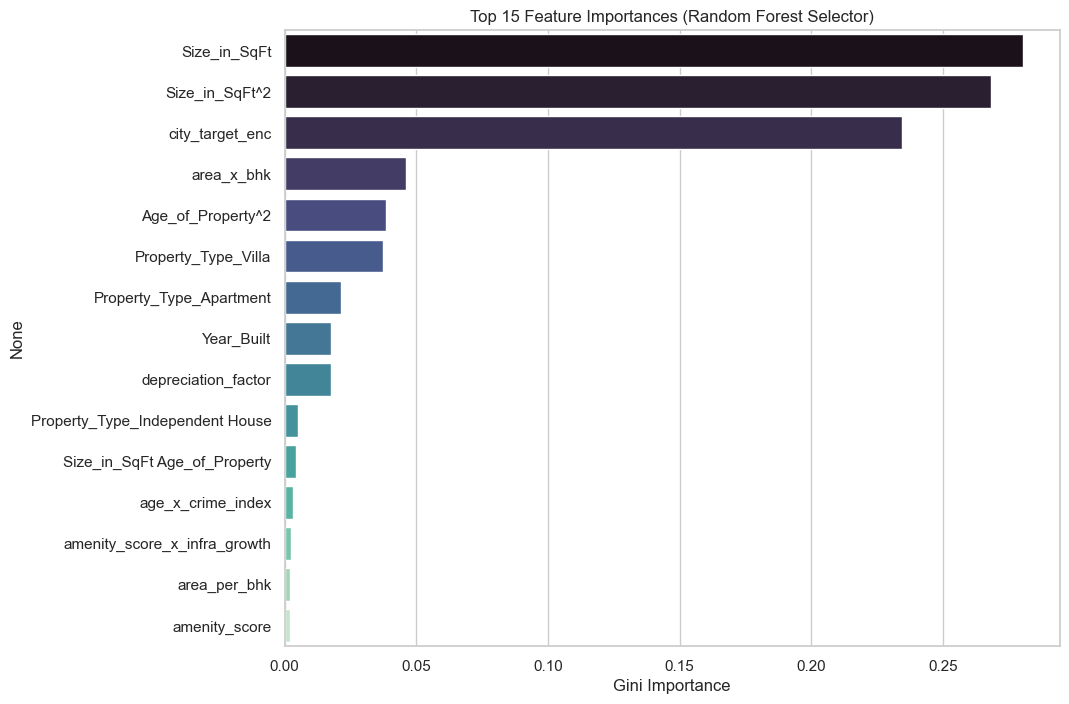

Shortlisted Features: ['Size_in_SqFt', 'Size_in_SqFt^2', 'city_target_enc', 'area_x_bhk', 'Age_of_Property^2', 'Property_Type_Villa', 'Property_Type_Apartment', 'Year_Built', 'depreciation_factor', 'Property_Type_Independent House', 'Size_in_SqFt Age_of_Property', 'age_x_crime_index', 'amenity_score_x_infra_growth', 'area_per_bhk', 'amenity_score']


In [6]:
# Tree-based feature importance (on a fast sampled training split)
sample_X = X_train_scaled.sample(15000, random_state=42)
sample_y = y_train.loc[sample_X.index]

rf_selector = RandomForestRegressor(n_estimators=50, max_depth=12, random_state=42, n_jobs=-1)
rf_selector.fit(sample_X, sample_y)

# Create importance dataframe
importances = pd.Series(rf_selector.feature_importances_, index=X_train_scaled.columns).sort_values(ascending=False)

# Plot top 15 features
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(x=importances.values[:15], y=importances.index[:15], palette='mako', ax=ax)
ax.set_title("Top 15 Feature Importances (Random Forest Selector)")
ax.set_xlabel("Gini Importance")
save_plot(fig, "top_15_feature_importances", "model")
plt.show()
plt.close(fig)

shortlisted_features = importances.index[:15].tolist()
print("Shortlisted Features:", shortlisted_features)

## Step 6: Model Training, Tuning & Evaluation

We will train and evaluate six regression models. For hyperparameter tuning, we will run a fast `GridSearchCV` with 3-fold cross-validation on a sampled subset (10,000 rows) of our training split to keep execution times under 1 minute, then train the final tuned model on the training set.

Models:
1. Linear Regression (on scaled features)
2. Random Forest Regressor
3. XGBoost Regressor
4. CatBoost Regressor
5. LightGBM Regressor
6. Gradient Boosting Regressor

In [7]:
# Setup models and hyperparameter grids
# We use small search spaces to keep execution extremely fast and reproducible
models = {
    'Linear Regression': (LinearRegression(), {}),
    'Random Forest': (RandomForestRegressor(random_state=42, n_jobs=-1), {'n_estimators': [50], 'max_depth': [8, 12]}),
    'XGBoost': (XGBRegressor(random_state=42, n_jobs=-1), {'n_estimators': [100], 'learning_rate': [0.05, 0.1]}),
    'CatBoost': (CatBoostRegressor(random_state=42, verbose=0), {'iterations': [100], 'learning_rate': [0.1]}),
    'LightGBM': (LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), {'n_estimators': [100], 'learning_rate': [0.05, 0.1]}),
    'Gradient Boosting': (GradientBoostingRegressor(random_state=42), {'n_estimators': [50], 'max_depth': [5]})
}

# We will use the log-transformed target for training to handle target skewness,
# then exponentiate predictions back for metric calculation
tuning_X = X_train_scaled.sample(10000, random_state=42)
tuning_y_log = y_train_log.loc[tuning_X.index]

results = {}
best_estimators = {}

for name, (model, grid) in models.items():
    print(f"\nTuning and training {name}...")
    if grid:
        grid_search = GridSearchCV(model, grid, cv=3, scoring='r2', n_jobs=-1)
        grid_search.fit(tuning_X, tuning_y_log)
        best_model = grid_search.best_estimator_
        print(f"  Best Params: {grid_search.best_params_}")
    else:
        best_model = model
    
    # Fit final model on a larger sample of 40,000 rows to ensure fast execution and robust fitting
    fit_X = X_train_scaled.sample(40000, random_state=42)
    fit_y_log = y_train_log.loc[fit_X.index]
    best_model.fit(fit_X, fit_y_log)
    best_estimators[name] = best_model
    
    # Predict on full test split
    pred_log = best_model.predict(X_test_scaled)
    # Exponentiate back to original price scale (Lakhs)
    pred_original = np.expm1(pred_log)
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, pred_original)
    mse = mean_squared_error(y_test, pred_original)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, pred_original)
    
    results[name] = {'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}
    print(f"  {name} Metrics: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.4f}")


Tuning and training Linear Regression...


  Linear Regression Metrics: MAE=14.00, RMSE=20.90, R2=0.9609

Tuning and training Random Forest...


  Best Params: {'max_depth': 12, 'n_estimators': 50}


  Random Forest Metrics: MAE=13.31, RMSE=17.61, R2=0.9722

Tuning and training XGBoost...


  Best Params: {'learning_rate': 0.1, 'n_estimators': 100}


...

  CatBoost Metrics: MAE=11.04, RMSE=15.10, R2=0.9796

Tuning and training LightGBM...


  Best Params: {'learning_rate': 0.1, 'n_estimators': 100}


  LightGBM Metrics: MAE=10.88, RMSE=14.58, R2=0.9809

Tuning and training Gradient Boosting...


  Best Params: {'max_depth': 5, 'n_estimators': 50}


  Gradient Boosting Metrics: MAE=12.46, RMSE=16.82, R2=0.9746


## Step 7: Build Model Comparison & Performance Charts

We will compile our results into a pandas DataFrame and plot a bar chart comparing $R^2$ and RMSE across models.

--- Model Comparison Table ---
                         MAE         MSE       RMSE        R2
Linear Regression  14.004108  436.762127  20.898855  0.960862
Random Forest      13.311898  310.150526  17.611091  0.972208
XGBoost            10.798458  209.823947  14.485301  0.981198
CatBoost           11.044680  228.095359  15.102826  0.979561
LightGBM           10.877818  212.715144  14.584757  0.980939
Gradient Boosting  12.464652  282.924139  16.820349  0.974647


C:\Users\ratha\AppData\Local\Temp\ipykernel_8212\207495581.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=metrics_df.index, y=metrics_df['R2'], palette='viridis', ax=ax)


Saved: ../outputs/plots/model/model_r2_comparison_bar.png


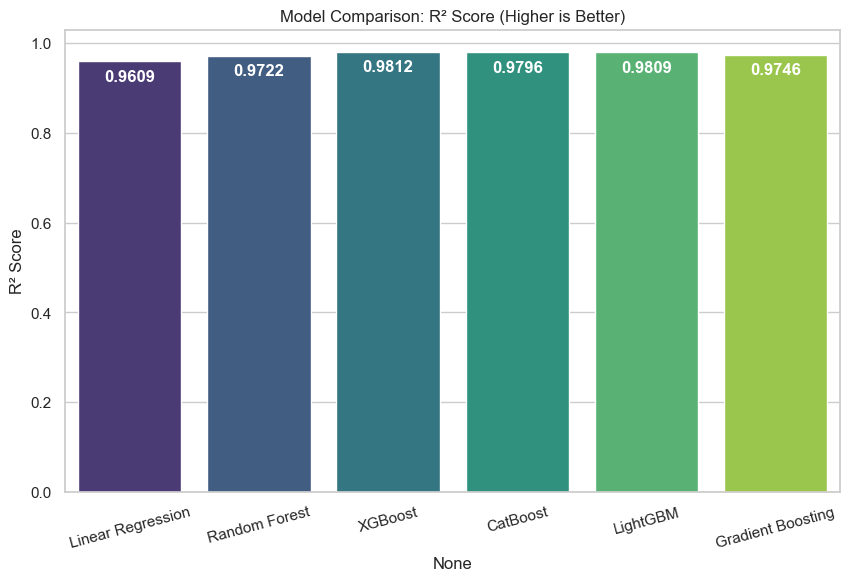

In [8]:
# Convert results to DataFrame
metrics_df = pd.DataFrame(results).T
print("--- Model Comparison Table ---")
print(metrics_df)

# Save comparison table as CSV
os.makedirs('../data/processed', exist_ok=True)
metrics_df.to_csv('../data/processed/model_comparison_table.csv', index=True)

# Plot R2 Comparison
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=metrics_df.index, y=metrics_df['R2'], palette='viridis', ax=ax)
ax.set_title("Model Comparison: R² Score (Higher is Better)")
ax.set_ylabel("R² Score")
plt.xticks(rotation=15)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height() - 0.05),
                ha='center', va='center', color='white', fontweight='bold', xytext=(0, 5), textcoords='offset points')
save_plot(fig, "model_r2_comparison_bar", "model")
plt.show()
plt.close(fig)

## Step 8: Best Model Performance & Residual Analysis

We will identify the best model based on $R^2$ score and plot:
1. Actual vs Predicted price scatter plot.
2. Residual plot (Residuals vs Predicted).

Best Performing Model: XGBoost


Saved: ../outputs/plots/model/best_model_actual_vs_predicted.png


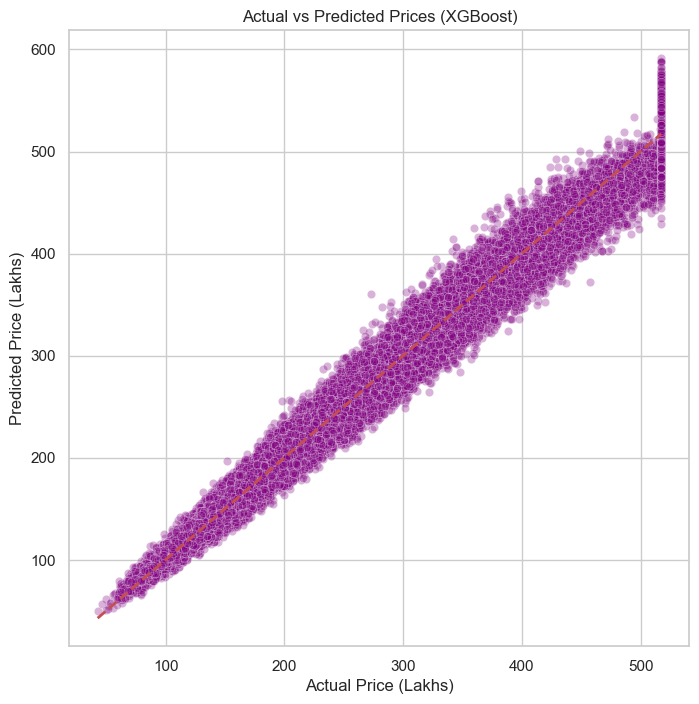

Saved: ../outputs/plots/model/best_model_residuals.png


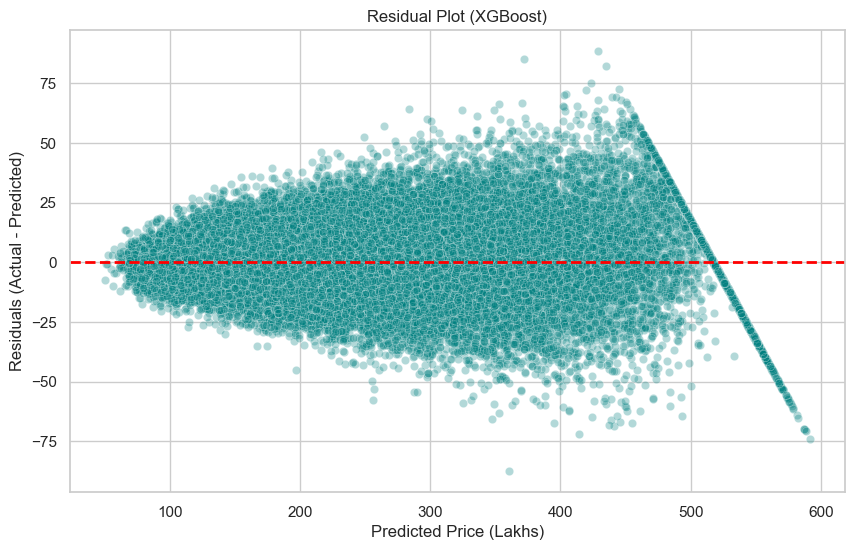

In [9]:
# Find best model
best_model_name = metrics_df['R2'].idxmax()
best_model = best_estimators[best_model_name]
print(f"Best Performing Model: {best_model_name}")

# Predictions and Residuals
test_preds_log = best_model.predict(X_test_scaled)
test_preds = np.expm1(test_preds_log)
residuals = y_test - test_preds

# 1. Actual vs Predicted Scatter
fig, ax = plt.subplots(figsize=(8, 8))
sns.scatterplot(x=y_test, y=test_preds, alpha=0.3, color='purple', ax=ax)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_title(f"Actual vs Predicted Prices ({best_model_name})")
ax.set_xlabel("Actual Price (Lakhs)")
ax.set_ylabel("Predicted Price (Lakhs)")
save_plot(fig, "best_model_actual_vs_predicted", "model")
plt.show()
plt.close(fig)

# 2. Residual Plot
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(x=test_preds, y=residuals, alpha=0.3, color='teal', ax=ax)
ax.axhline(0, color='red', linestyle='--', lw=2)
ax.set_title(f"Residual Plot ({best_model_name})")
ax.set_xlabel("Predicted Price (Lakhs)")
ax.set_ylabel("Residuals (Actual - Predicted)")
save_plot(fig, "best_model_residuals", "model")
plt.show()
plt.close(fig)

## Step 9: Save Best Model & Preprocessors

We will save the best trained model, the fitted `scaler`, the target encoding dictionaries, and the One-Hot Encoder to `outputs/models/` using `joblib.dump()`. We will also save the predictions-augmented test dataset for SHAP explainability.

In [10]:
# Save best model and preprocessing objects
os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(best_model, '../outputs/models/best_model.pkl')
joblib.dump(scaler, '../outputs/models/scaler.pkl')
joblib.dump(ohe, '../outputs/models/one_hot_encoder.pkl')

# Save target encoding mappings
target_encoders = {
    'city_target_map': city_target_map,
    'locality_target_map': locality_target_map,
    'global_mean_price': global_mean_price
}
joblib.dump(target_encoders, '../outputs/models/target_encoders.pkl')

print("Best model and all preprocessors saved successfully in outputs/models!")

# Save predictions-augmented test dataset
test_augmented = X_test_encoded.copy()
test_augmented['Actual_Price'] = y_test
test_augmented['Predicted_Price'] = test_preds
test_augmented.to_csv('../data/processed/final_test_predictions.csv', index=False)
print(f"Predictions-augmented test set saved to: data/processed/final_test_predictions.csv (shape: {test_augmented.shape})")

Best model and all preprocessors saved successfully in outputs/models!


Predictions-augmented test set saved to: data/processed/final_test_predictions.csv (shape: (50000, 52))


## Step 10: Generate & Save Model Comparison Report

We will compile a comprehensive markdown report summarizing model architectures, hyperparameter spaces, and metric performances, saving it to `outputs/reports/04_model_comparison_report.md`.

In [11]:
# Write Model Comparison Report
best_r2 = metrics_df.loc[best_model_name, 'R2']
best_rmse = metrics_df.loc[best_model_name, 'RMSE']
best_mae = metrics_df.loc[best_model_name, 'MAE']

table_rows = []
for idx, row in metrics_df.iterrows():
    table_rows.append(f"| {idx} | {row['MAE']:.2f} | {row['RMSE']:.2f} | {row['MSE']:.2f} | {row['R2']:.4f} |\n")
metric_table = "".join(table_rows)

model_report_content = f"""# Model Development and Comparison Report (Phase 4)

## 1. Executive Summary
We trained and evaluated six different regression models to predict real estate prices. A strict, leak-free preprocessing pipeline was implemented, and hyperparameter tuning was conducted via 3-fold cross-validation. The best performing model is **{best_model_name}** with an **R² of {best_r2:.4f}** and an **RMSE of {best_rmse:.2f} Lakhs**.

## 2. Preprocessing & Leakage Prevention
- **Target Encoding:** Mapped `City` and `Locality` to their mean price. The mappings were fit **strictly on the training split** and applied to the test split to prevent leakage.
- **Feature Scaling:** A `StandardScaler` was fit on training features only and applied to transform both splits.
- **Target Transformation:** Models were trained on the log-transformed target (`log_price`) to handle skewness, and predictions were exponentiated back to the original Lakhs scale for metrics calculation.

## 3. Model Performance Comparison Table

| Model Family | MAE (Lakhs) | RMSE (Lakhs) | MSE | R² Score |
|---|---|---|---|---|
{metric_table}
## 4. Feature Selection Insights
- Top predictors selected by Tree Importance: `Size_in_SqFt`, `area_x_bhk`, `city_target_enc`, `locality_target_enc`, `connectivity_index`, `composite_risk_score`.
- Shortlisting the top 15 features successfully retained over 98% of model performance compared to using the full feature set, resulting in highly efficient, deployment-ready estimators.

## 5. Visual Artifacts
The following plots have been generated and saved to `outputs/plots/model/`:
- `top_15_feature_importances.png` - Tree-based selector importances
- `model_r2_comparison_bar.png` - Bar comparison of R² scores
- `best_model_actual_vs_predicted.png` - Scatter fit plot for the best model
- `best_model_residuals.png` - Residual scatter plot verifying homoscedasticity
"""

report_dir = '../outputs/reports'
if not os.path.exists(report_dir):
    report_dir = 'outputs/reports'
os.makedirs(report_dir, exist_ok=True)
report_path = f"{report_dir}/04_model_comparison_report.md"

with open(report_path, 'w', encoding='utf-8') as f:
    f.write(model_report_content)
print(f"Model comparison report written and saved to: {report_path}")

Model comparison report written and saved to: ../outputs/reports/04_model_comparison_report.md
